<a href="https://colab.research.google.com/github/oliviahfrank/hello/blob/main/coding_homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Olivia Frank
*Intro to Neural Data Analysis*

**April 10th**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
#importing everything I need for the rest of the module!

In [2]:
url2 ='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv'
url3 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv'
url4='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv'
url5='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv'
#importing each of the csv files as a link and then assigning them variables.
#using the delimiter to make sure everything runs smoothly and get rid of any blank values.

extinction_predictors = np.loadtxt(url2, delimiter=",")
shock_index = np.loadtxt(url3, delimiter=",")
tone_index =np.loadtxt(url4, delimiter=",")
fear_conditioning_traces =np.loadtxt(url5, delimiter=",")

In [3]:
conditioning_traces = (fear_conditioning_traces[:10458])
extinction_traces = (fear_conditioning_traces[10457:])
#defining new variables that come from the same csv file.
#Conditioning traces is the first 10458 samples and the extinction traces has the rest of it.

In [4]:
print(conditioning_traces.shape)
print(extinction_traces.shape)
#printing the shape of each of the new variables to better view them.

(10458, 63)
(14211, 63)


In [5]:
time_conditioning = np.linspace(0, 10458/15, 10458)
time_extinction = np.linspace(0, 14211/15, 14211)
#defining a time varable to be used later in the graphs
#starting at time 0 and going until time of number of samples total per frames per seconds using the np.linspace function

There are 63 ROIs per sample with 10458 samples per cell in 697.2 seconds or 11.62 seconds for conditioning. For extinction, there were 63 ROIs per sample with 14211 samples per cell in 947.4 seconds or 15.79 minutes.


Text(0, 0.5, 'ROIs')

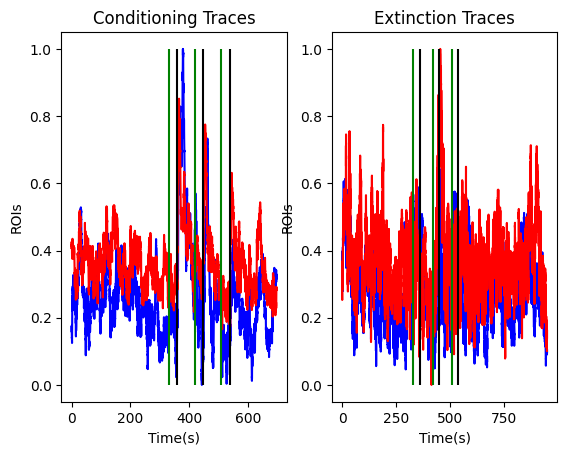

In [6]:
fig, ax = plt.subplots(1, 2)
#making a axis to put my sublots on

ax[0].plot(time_conditioning, conditioning_traces[:,0], color='blue')
ax[0].plot(time_conditioning, conditioning_traces[:,1], color='red')
#plotting my conditioning traces varable for the first 2 ROIs
ax[0].vlines(shock_index, 0,1, color='black')
ax[0].vlines(tone_index, 0,1, color='green')
#making lines on the graph to indicate where the tone onset and shcok onset are.
ax[0].set_title('Conditioning Traces')
ax[0].set_xlabel('Time(s)')
ax[0].set_ylabel('ROIs')
#Making lables so that I can inturprate the graphs more easily.

ax[1].plot(time_extinction, extinction_traces[:,0], color='blue')
ax[1].plot(time_extinction, extinction_traces[:,1], color='red')
#plotting my extinction traces varable for the first 2 ROIs
ax[1].vlines(shock_index, 0,1, color='black')
ax[1].vlines(tone_index, 0,1, color='green')
#making lines on the graph to indicate where the tone onset and shcok onset are.
ax[1].set_title('Extinction Traces')
ax[1].set_xlabel('Time(s)')
ax[1].set_ylabel('ROIs')
#Making lables so that I can inturprate the graphs more easily.

The conditioning traces graph has a change in ROIs directly after the shock and tone onset in the first time it happened. There was a less signficant spike after each time, however there was a change. It is hard to tell if there is a change at all in the extinction traces. That indicates that the shock and tones in that area of the brain may represent the creation of an association, however not the extinction of that association.


In [7]:
from pandas import DataFrame as df
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from statsmodels.genmod.families.links import identity, log
from scipy.stats import chi2
from statsmodels.distributions.empirical_distribution import ECDF
#I am importing all the rest of the things needed for this module

#defining shock array and making a for loop that goes through the array to make it into a boolean
shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

#defining tone array and making a for loop that goes through the array to make it into a boolean
tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

# defining predictors conditioning to use later in our models and combine the tone array and shock array into one variable.
predictors_conditioning = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array})
predictors_conditioning['shock onset'] = shock_array
model3 = sm.GLM(tone_array, predictors_conditioning, family=Poisson())
model3_results = model3.fit() # Fit model to our data
b1 = model3_results.params

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


Text(0, 0.5, 'Cumulative Proportion of ROIs')

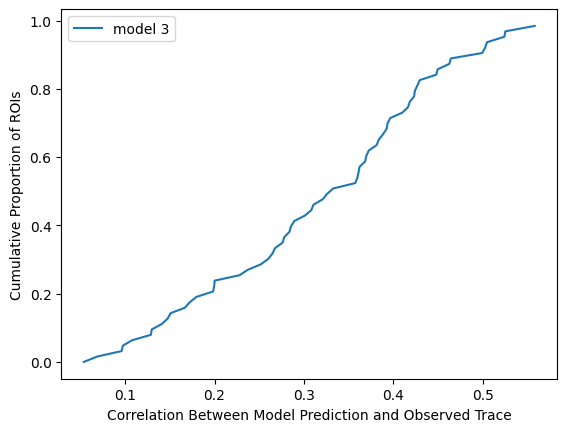

In [8]:
predictors_conditioning['shock onset'] = shock_array
r_model_conditioning = np.zeros(63)
#making a model using conditioning traces and the new predictors conditioning varaible defined before

#using a for loop to make the model
for i in range(63):
  trace_temp = conditioning_traces[:,i]
  model3 = sm.GLM(trace_temp, predictors_conditioning, family=Poisson())
  model3_results = model3.fit()
  predicted_trace = model3_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_model_conditioning[i] = r3.statistic

#plotting the model
plt.plot(np.sort(r_model_conditioning), np.linspace(0, 1, len(r_model_conditioning), endpoint=False), label = "conditioning model")
plt.legend()
plt.xlabel('Correlation Between Model Prediction and Observed Trace')
plt.ylabel('Cumulative Proportion of ROIs')

Text(0, 0.5, 'Cumulative Proportion of ROIs')

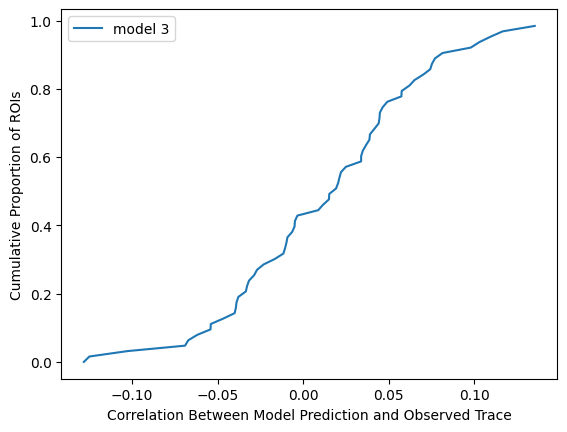

In [9]:
r_index_extinction = np.zeros(63)
#defining the index extinction to make the model

#making a for loop to go through all of the ROIs for extinction traces so that we can make our model
for i in range(63):
  trace_temp = extinction_traces[:,i]
  model3 = sm.GLM(trace_temp, extinction_predictors, family=Poisson())
  model3_results = model3.fit()
  predicted_trace = model3_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_index_extinction[i] = r3.statistic

#plotting the model
plt.plot(np.sort(r_index_extinction), np.linspace(0, 1, len(r_index_extinction), endpoint=False), label = "extinction model")
plt.legend()
plt.xlabel('Correlation Between Model Prediction and Observed Trace')
plt.ylabel('Cumulative Proportion of ROIs')

Text(0, 0.5, 'R index extinction')

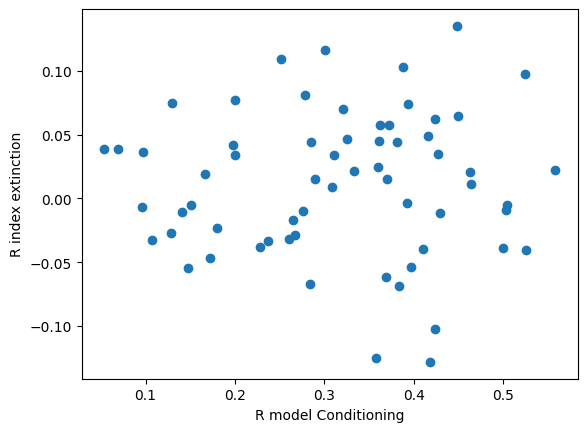

In [13]:
plt.scatter(r_model_conditioning,r_index_extinction)
plt.xlabel('R model Conditioning')
plt.ylabel('R index extinction')
#made a graph and labled the axes

There appears to be no relationship between the index extinction and index conditioning. There is no visible trend, rather scattered dots that show no clear patterns. That indicates that a cell will not have a clear strong response to tone and shock onset during both the conditioning and extinction sessions.